# Sklearn: Classification
> Predicting categories — spam/not spam, disease/healthy, cat/dog*

## What is Classification?
Classification predicts which **category** an input belongs to — unlike regression, which predicts a continuous number.

**Input:** features describing an observation
**Output:** a discrete class label (e.g. malignant / benign, spam / not spam, cat / dog)

This notebook covers four classifiers on the same dataset so you can compare them directly:

| Model | Core idea | Scaling needed |
|-------|-----------|---------------|
| Logistic Regression | Fits a probability with the sigmoid function | Yes |
| K-Nearest Neighbors | Votes based on the K closest training points | Yes |
| Decision Tree | Splits data with yes/no questions on features | No |
| Random Forest | Averages many decision trees (ensemble/bagging) | No |

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
print("Imports done")

Imports done


## 1. Load Dataset — Breast Cancer Wisconsin
A binary classification dataset from the UCI repository. Each row is a digitized image of a fine needle aspirate (FNA) of a breast mass.

**Target:** `diagnosis` — whether the tumor is malignant or benign
- `0` = malignant (cancerous)
- `1` = benign (non-cancerous)

**Features (30 total):** Measurements computed from cell nuclei in the image — radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, and fractal dimension. Each is recorded as its mean, standard error, and worst (largest) value across the nuclei.

**Why this dataset?** Real-world medical use case, well-balanced classes, small enough to train instantly, but challenging enough to show meaningful differences between models.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame
df['diagnosis'] = data.target  # 0=malignant, 1=benign

print("Shape:", df.shape)
print("Classes:", dict(zip([0,1], data.target_names)))
print()
print("Class balance:")
print(df['diagnosis'].value_counts())
print()
df.head(3)

Shape: (569, 32)
Classes: {0: 'malignant', 1: 'benign'}

Class balance:
diagnosis
1    357
0    212
Name: count, dtype: int64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,0


In [3]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (455, 30), Test: (114, 30)


## 2. Logistic Regression
Despite the name, Logistic Regression is a **classifier**, not a regressor. It models the probability that an input belongs to a class using the **sigmoid function**, which squashes any number into the range (0, 1).

**Math:** `P(y=1 | x) = σ(w·x + b)` where `σ(z) = 1 / (1 + e⁻ᶻ)`

- If the predicted probability > 0.5 → predict class 1, otherwise class 0
- The decision boundary is **linear** — a straight line (or hyperplane) separating the classes
- Coefficients tell you the direction and strength of each feature's influence

**Pros:** Fast to train, interpretable coefficients, outputs calibrated probabilities
**Cons:** Assumes a linear boundary — fails when the true boundary is curved or complex

In [4]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:, 1]  # probability of class 1

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

=== Logistic Regression ===
Accuracy:  0.9825
ROC-AUC:   0.9954

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Confusion Matrix
Shows exactly what the model got right and wrong, broken down by class — more informative than a single accuracy number.

```
                   Predicted
                Negative | Positive
Actual Negative |   TN   |   FP   (False Alarm)
Actual Positive |   FN   |   TP
                  (Missed)
```

- **True Positive (TP):** Correctly predicted positive
- **True Negative (TN):** Correctly predicted negative
- **False Positive (FP):** Predicted positive, actually negative — a "false alarm"
- **False Negative (FN):** Predicted negative, actually positive — a "missed case"

In medical contexts, **FN is the most dangerous** — telling a sick patient they are healthy.

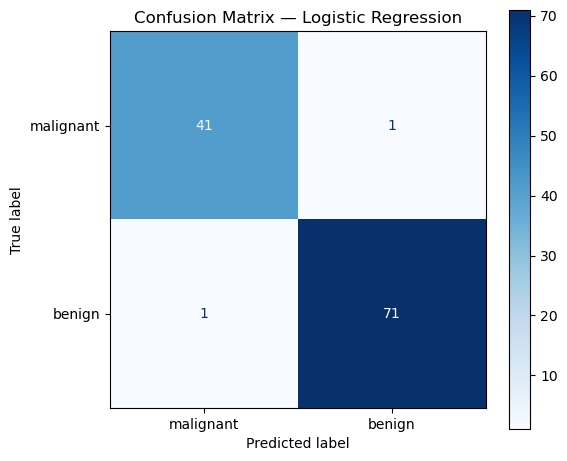

In [5]:
# Confusion Matrix — understand WHAT the model gets wrong
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=data.target_names,
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()
# Rows = actual, Columns = predicted
# Top-left = True Negatives, Bottom-right = True Positives

## 3. K-Nearest Neighbors (KNN)
KNN is a **lazy learner** — it does no training at all. At prediction time it finds the K most similar training examples and takes a majority vote.

**How it works:**
1. Compute the distance from the new point to every training point (Euclidean distance by default)
2. Select the K closest points
3. Predict the majority class among those K neighbors

**Effect of K:**
- **Small K (e.g. K=1):** Fits training data perfectly — very sensitive to noise, jagged boundaries, overfitting
- **Large K:** Smoother, more stable boundaries — but may underfit if K is too large
- The right K balances these two extremes (found by testing on validation data)

**Pros:** Simple, no training time, naturally handles multi-class problems
**Cons:** Slow at prediction on large datasets (must scan all training points), must scale features, sensitive to irrelevant features

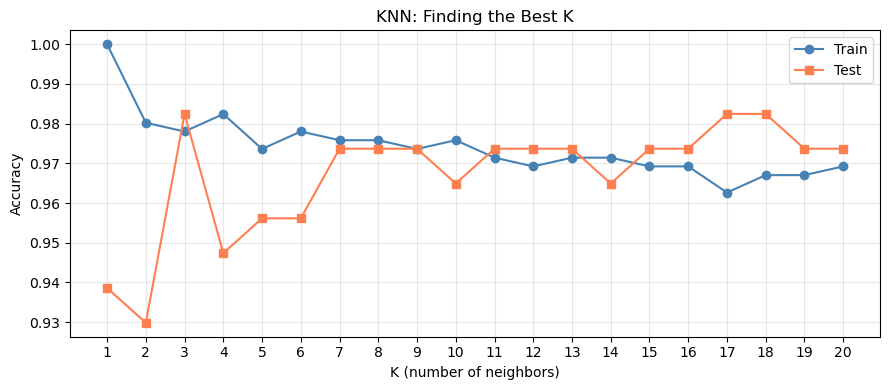

In [6]:
# Find best K
k_values = range(1, 21)
train_scores, test_scores = [], []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(k_values, train_scores, 'o-', label='Train', color='steelblue')
plt.plot(k_values, test_scores, 's-', label='Test', color='coral')
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Finding the Best K")
plt.legend()
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Small K = overfitting (wiggly). Large K = underfitting (too smooth). Find the sweet spot.

In [7]:
best_k = k_values[np.argmax(test_scores)]
print(f"Best K: {best_k} — Test Accuracy: {max(test_scores):.4f}")

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn.fit(X_train, y_train)

Best K: 3 — Test Accuracy: 0.9825


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=3))])

## 4. Decision Tree
Learns a sequence of yes/no questions about features to progressively split the data into purer groups. The result is a tree structure you can draw, read, and explain to a non-technical audience.

**How splitting works:** At each node, the algorithm picks the feature and threshold that best separates the classes — measured by **Gini impurity**:

`Gini = 1 − Σ(pᵢ²)` — 0 means a perfectly pure node (all one class), 0.5 means maximally mixed.

**Effect of `max_depth`:**
- **No limit:** Tree grows until every leaf is pure → perfect training accuracy, severe overfitting
- **Shallow (e.g. depth 2–3):** High bias, may underfit but very interpretable
- **Tuned depth:** The sweet spot between fitting the data and generalizing to new data

**Pros:** Highly interpretable, handles mixed feature types, no scaling required
**Cons:** Prone to overfitting without constraints, unstable (small changes in data → very different tree)

In [8]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, random_state=42))
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print()
print("Effect of max_depth on train vs test accuracy:")
print(f"{'Depth':>6} {'Train':>8} {'Test':>8}")
for d in range(1, 15):
    pipe = Pipeline([('s', StandardScaler()), ('m', DecisionTreeClassifier(max_depth=d, random_state=42))])
    pipe.fit(X_train, y_train)
    print(f"{d:>6} {pipe.score(X_train, y_train):>8.4f} {pipe.score(X_test, y_test):>8.4f}")

Decision Tree Accuracy: 0.9386

Effect of max_depth on train vs test accuracy:
 Depth    Train     Test
     1   0.9231   0.9211
     2   0.9582   0.8947
     3   0.9758   0.9386
     4   0.9868   0.9386
     5   0.9934   0.9211
     6   0.9978   0.9123
     7   1.0000   0.9123
     8   1.0000   0.9123
     9   1.0000   0.9123
    10   1.0000   0.9123
    11   1.0000   0.9123
    12   1.0000   0.9123
    13   1.0000   0.9123
    14   1.0000   0.9123


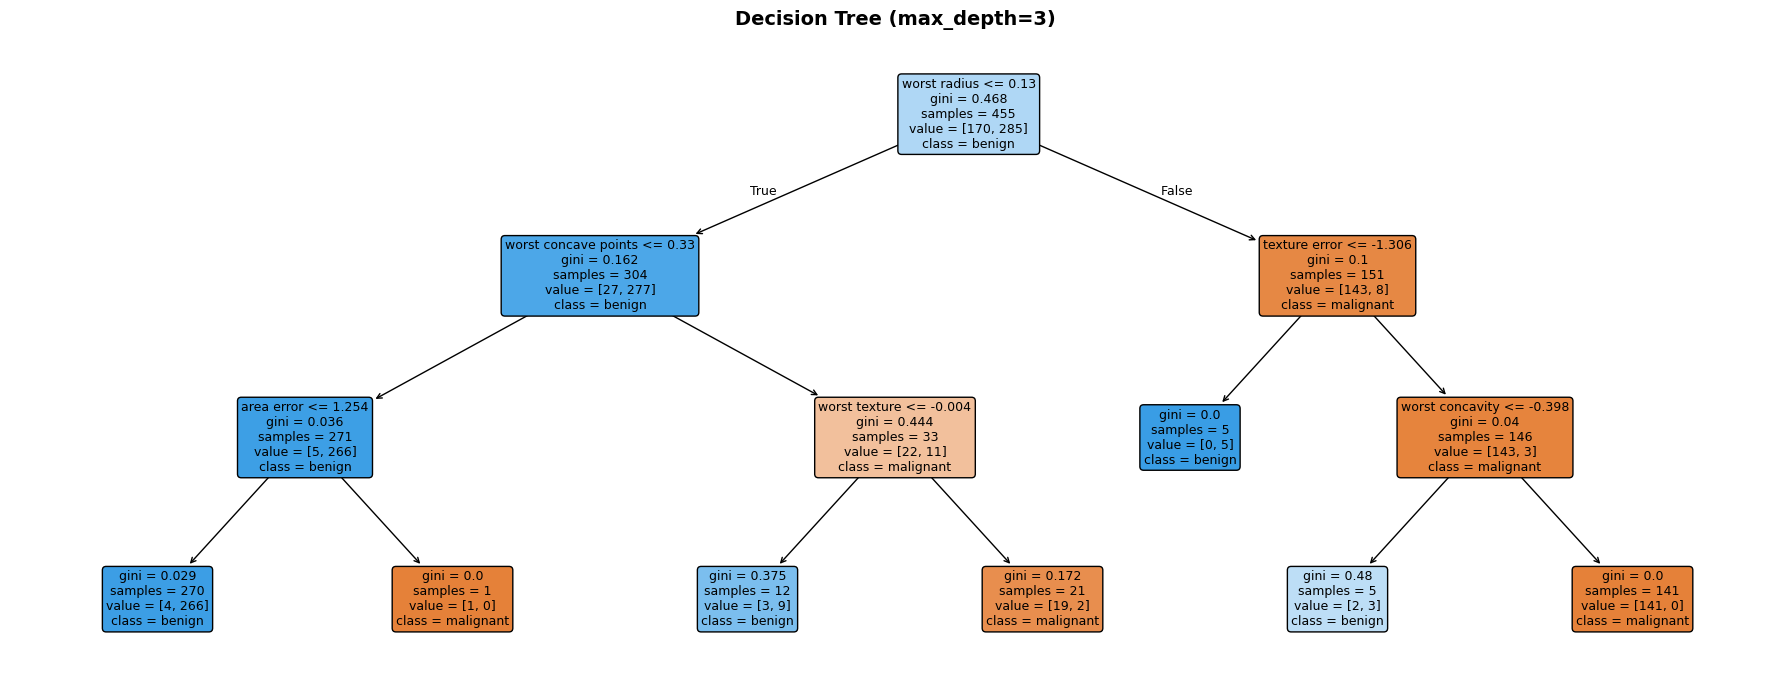

In [9]:
# Visualize the tree (limited to depth 3 for readability)
pipe_viz = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=3, random_state=42))
])
pipe_viz.fit(X_train, y_train)

plt.figure(figsize=(18, 7))
plot_tree(
    pipe_viz.named_steps['model'],
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True, rounded=True, fontsize=9
)
plt.title("Decision Tree (max_depth=3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Random Forest
An **ensemble** of decision trees. Each tree is trained on a random bootstrap sample of the data, and at each split only a random subset of features is considered. Final prediction = majority vote across all trees.

**Why this reduces overfitting:**
Each tree is different (different data sample, different features considered). Individual trees make different errors — averaging uncorrelated errors cancels them out. This technique is called **bagging** (Bootstrap Aggregating).

**Key hyperparameters:**
- `n_estimators` — number of trees (more = better and more stable, but slower; 100–500 is typical)
- `max_depth` — depth of each individual tree (default: unlimited)
- `max_features` — features considered at each split (default: `sqrt(n_features)` for classification)

**Feature importance:** Random Forest can rank features by how much they reduce impurity across all trees — a useful tool for understanding which inputs actually matter.

**Pros:** Robust to overfitting, gives feature importances, no scaling needed, best out-of-the-box accuracy
**Cons:** Less interpretable than a single tree, slower to train and predict, high memory usage with many trees

In [10]:
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Note: No scaler needed for tree-based models

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf  = pipe_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

=== Random Forest ===
Accuracy: 0.9561
ROC-AUC:  0.9937

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



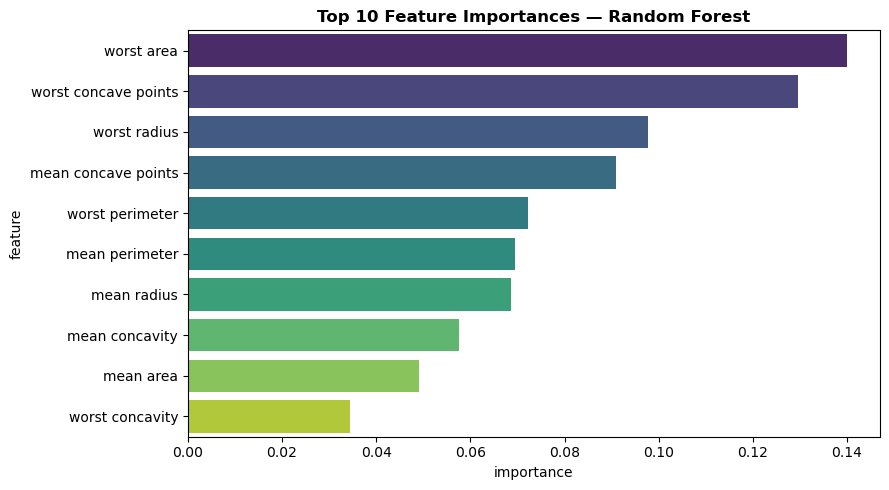

In [11]:
# Feature importance — what did the forest find useful?
importances = pipe_rf.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': data.feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title("Top 10 Feature Importances — Random Forest", fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Comparison + ROC Curve

**ROC Curve (Receiver Operating Characteristic):**
Plots the **True Positive Rate** (recall) against the **False Positive Rate** at every possible classification threshold — not just the default 0.5 cutoff.

`TPR = TP / (TP + FN)` — what fraction of actual positives did we catch?
`FPR = FP / (FP + TN)` — what fraction of actual negatives did we wrongly flag?

**AUC (Area Under the Curve):**
- `1.0` = perfect classifier
- `0.5` = no better than random guessing (the diagonal dashed line)
- A curve closer to the **top-left corner** = better model at all thresholds

**When to prefer AUC over accuracy:** When classes are imbalanced, or when the cost of false positives vs false negatives differs (e.g. medical diagnosis — missing a cancer is far worse than a false alarm).

In [12]:
models = {
    'Logistic Regression': (pipe_lr, y_prob),
    f'KNN (k={best_k})':   (pipe_knn, pipe_knn.predict_proba(X_test)[:, 1]),
    'Decision Tree':       (pipe_dt, pipe_dt.predict_proba(X_test)[:, 1]),
    'Random Forest':       (pipe_rf, y_prob_rf),
}

print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
for name, (pipe, prob) in models.items():
    acc = accuracy_score(y_test, pipe.predict(X_test))
    auc = roc_auc_score(y_test, prob)
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f}")

Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           0.9825     0.9954
KNN (k=3)                     0.9825     0.9835
Decision Tree                 0.9386     0.9342
Random Forest                 0.9561     0.9937


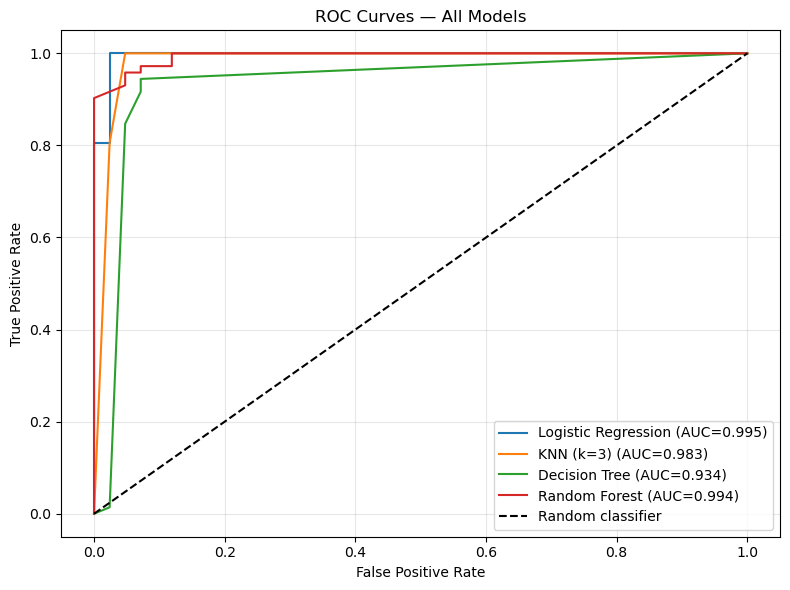

In [13]:
# ROC Curves
plt.figure(figsize=(8, 6))
for name, (pipe, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Curve closer to top-left corner = better model

## Key Takeaways

| Model | Needs Scaling | Interpretable | Best For |
|---|---|---|---|
| Logistic Regression | Yes | Yes | Linear boundaries, when you need probabilities |
| KNN | Yes | Partly | Small datasets, no distributional assumptions |
| Decision Tree | No | Yes | Explainability, mixed feature types |
| Random Forest | No | No | Best general-purpose accuracy out of the box |

**Metrics summary:**
- **Accuracy** — reliable only when classes are balanced
- **Precision** — of all predicted positives, how many were actually correct (minimize false alarms)
- **Recall** — of all actual positives, how many did the model catch (minimize missed cases)
- **F1** — harmonic mean of precision and recall; use when both matter
- **ROC-AUC** — best single metric for binary classification, especially with imbalanced classes
- **Confusion matrix** — shows exactly where the model fails, not just the overall score